In [1]:
import geopandas as gpd
from shapely import wkt
from tqdm import tqdm
import pandas as pd
import os
import matplotlib as plt
import seaborn as sns

In [2]:
# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [3]:
def calculate_area_in_km2(gdf):
    """
    Calculate the area of each polygon in the GeoDataFrame in square kilometers.

    Parameters:
    gdf (GeoDataFrame): GeoDataFrame with geometries in WKT format.

    Returns:
    GeoDataFrame: GeoDataFrame with an added column for area in square kilometers.
    """
    # Step 1: Set target CRS to EPSG:4326
    target_crs = 'EPSG:4326'
    gdf = gdf.to_crs(target_crs)
    
    # Step 2: Reproject to a CRS with meters (e.g., EPSG:3857)
    projected_gdf = gdf.to_crs('EPSG:3857')
    
    # Step 3: Calculate the area in square meters
    projected_gdf['area_m2'] = projected_gdf.geometry.area
    
    # Step 4: Convert the area to square kilometers
    projected_gdf['area_km2'] = projected_gdf['area_m2'] / 1e6
    
    # Step 5: Assign the calculated area to a new column in the original GeoDataFrame
    gdf['area_km2'] = projected_gdf['area_km2']
    
    # Step 6: Return the modified GeoDataFrame
    return gdf

/tmp/ipykernel_3151232/1560317565.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area'] = gdf['geometry'].area


                                            geometry      area
0  POLYGON ((-81.35100 31.59693, -81.35100 31.689...  0.010032
Bounding Box Area (in square meters): 0.010031539227765313


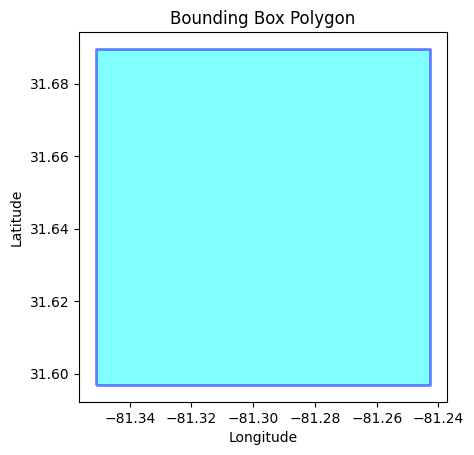

In [4]:
import xarray as xr
import numpy as np
import shapely.geometry
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Load the NetCDF file
mini="/Net/Groups/BGI/scratch/fmueller/Data/s2/512/bark_beetle/2017/1/1_2017_06.nc"
data = xr.open_dataset(mini)

# Example variables; replace with actual variable names
lat = data['lat']  # Latitude variable
lon = data['lon']  # Longitude variable

# Get the minimum and maximum values to define the bounding box
lat_min = lat.min().values
lat_max = lat.max().values
lon_min = lon.min().values
lon_max = lon.max().values

# Define the corners of the bounding box
bounding_box_coords = [
    (lon_min, lat_min),
    (lon_min, lat_max),
    (lon_max, lat_max),
    (lon_max, lat_min),
    (lon_min, lat_min)  # Closing the polygon
]

# Create the bounding box polygon
bounding_box = Polygon(bounding_box_coords)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame({'geometry': [bounding_box]}, crs='EPSG:4326')  # WGS84

# Calculate the area of the bounding box
# To get an accurate area in square meters, convert to an appropriate CRS
#gdf = gdf.to_crs(epsg=3857)  # Converting to Web Mercator projection for area calculation
gdf['area'] = gdf['geometry'].area

# Print the GeoDataFrame and area
print(gdf)
print("Bounding Box Area (in square meters):", gdf['area'].values[0])

# Visualize the bounding box
fig, ax = plt.subplots()
gdf.plot(ax=ax, edgecolor='blue', facecolor='cyan', alpha=0.5, linewidth=2)
ax.set_title('Bounding Box Polygon')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

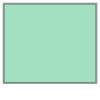

In [5]:
bounding_box

In [6]:
gdf = calculate_area_in_km2(gdf)
size = gdf[0:1]['area_km2'][0]
print(f'Size of Grid: {size} km²')

Size of Grid: 146.01972548517796 km²


In [4]:
# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [5]:
def format_label(label):
    return ' '.join(word.capitalize() for word in label.split('_'))


In [6]:
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#FFBA08', # tab:yellow
    'bark_beetle': '#714709'  # tab:brown
}

In [4]:
def remove_overlapping_entries(df, year_col='SURVEY_YEAR', geometry_col='geometry'):
    """
    Remove entries that overlap spatially within a given temporal window.

    Parameters:
    df (DataFrame): DataFrame containing the data.
    year_col (str): Name of the column containing the survey year.
    geometry_col (str): Name of the column containing geometry data.

    Returns:
    DataFrame: DataFrame with overlapping entries removed.
    """
    df = df.copy()
    overlaps = set()

    # Iterate over each row to check for overlaps with a progress bar
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Checking overlaps"):
        year = row[year_col]
        geom = row[geometry_col]

        # Define the time window for overlap check
        #time_window = (df[year_col] >= (year - 10)) & (df[year_col] <= (year + 5))
        time_window = (df[year_col] >= (year - 5)) & (df[year_col] <= (year + 5))

        # Check for spatial overlaps within the time window
        #spatial_overlaps = df[time_window][df[geometry_col].intersects(geom)]
        spatial_overlaps = df.loc[time_window & df[geometry_col].intersects(geom)]
        
        # Add the indices of the overlapping rows to the overlaps set
        if len(spatial_overlaps) > 1:
            overlaps.add(i)
            overlaps.update(spatial_overlaps.index)

    # Drop the overlapping rows
    df = df.drop(index=overlaps)
    return df

In [5]:
import pandas as pd
from tqdm import tqdm

def keep_overlapping_entries(df, id_col='ID_E', year_col='SURVEY_YEAR', geometry_col='geometry'):
    """
    Keep entries that overlap spatially within a ±1 year temporal window 
    and add a column 'ID_O' containing the IDs of overlapping elements.

    Parameters:
    df (DataFrame): DataFrame containing the data.
    id_col (str): Name of the column containing unique IDs (e.g., 'ID_E').
    year_col (str): Name of the column containing the survey year.
    geometry_col (str): Name of the column containing geometry data.

    Returns:
    DataFrame: DataFrame with overlapping entries and a new column 'ID_O' listing overlapping IDs.
    """
    df = df.copy()
    df['ID_O'] = None  # Initialize the ID_O column
    
    # Iterate over each row to check for overlaps with a progress bar
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Checking overlaps"):
        year = row[year_col]
        geom = row[geometry_col]
        id_e = row[id_col]
        
        # Define the time window for overlap check within ±1 year
        time_window = (df[year_col] >= (year - 1)) & (df[year_col] <= (year + 1))

        # Check for spatial overlaps within the time window
        spatial_overlaps = df.loc[time_window & df[geometry_col].intersects(geom)]

        # Exclude the current row from the overlaps
        spatial_overlaps = spatial_overlaps[spatial_overlaps[id_col] != id_e]

        # If overlaps are found, update the ID_O column
        if not spatial_overlaps.empty:
            df.at[i, 'ID_O'] = spatial_overlaps[id_col].tolist()

    # Return only the rows where there is an overlap (ID_O is not None)
    return df.dropna(subset=['ID_O'])

# Example usage:
# result_df = keep_overlapping_entries(df)


In [6]:
input_file = "/Net/Groups/BGI/work_2/ForExD/USDA/tables/CONUS_Region8_dissolved.csv"

# Step 1: Read the CSV file into a DataFrame
print("Step 1: Loading CSV file...")
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf = gdf.rename(columns={'Unnamed: 0': 'ID_E'})

# Set the coordinate reference system (CRS) if it's not already set
gdf.set_crs(epsg=4326, inplace=True)

print(f"Number of elements: {len(gdf)}")


Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Number of elements: 68916


In [6]:
print("Step 4: Removing temporal and spatial overlaps...")
gdf_no_overlap = remove_overlapping_entries(gdf)
print(f"Number of elements after removing temporal and spatial overlaps: {len(gdf_no_overlap)}")

Step 4: Removing temporal and spatial overlaps...


Checking overlaps: 100%|██████████| 68916/68916 [08:40<00:00, 132.45it/s]

Number of elements after removing temporal and spatial overlaps: 36608


In [7]:
print("Step 4: Checking for temporal and spatial overlaps +- 1 years...")
gdf_overlap = keep_overlapping_entries(gdf)
print(f"Number of elements with temporal and spatial overlaps: {len(gdf_overlap)}")

Step 4: Checking for temporal and spatial overlaps +- 1 years...


Checking overlaps: 100%|██████████| 68916/68916 [11:16<00:00, 101.90it/s]

Number of elements with temporal and spatial overlaps: 29951


In [8]:
gdf_overlap[0:4]

,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O
0,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,"[62, 2933, 3310, 3331, 11782, 12851, 13173, 17..."
4,4,defoliators,1998,"MULTIPOLYGON (((-91.25619 30.06854, -91.25474 ...",8,Defoliation,1,12021,2,NaN,baldcypress,221.0,4,"[55, 66, 9393, 10979, 11355, 12854, 13220, 140..."
5,5,defoliators,1998,"MULTIPOLYGON (((-90.76337 30.18860, -90.76184 ...",8,Defoliation,1,12021,2,NaN,baldcypress,221.0,0,"[56, 3137, 3870, 10471, 11951, 12817, 14691, 1..."
7,7,other_biotic,1999,"MULTIPOLYGON (((-79.93646 38.11799, -79.93576 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,6,"[10, 10061, 19832, 20403]"


In [9]:
import pandas as pd
from tqdm import tqdm

def analyze_overlaps(gdf_overlap, id_col='ID_E', year_col='SURVEY_YEAR', dca_id_col='DCA_ID'):
    """
    Analyze overlaps to find the longest duration between overlapping entries
    and count the unique DCA_IDs.

    Parameters:
    gdf_overlap (DataFrame): DataFrame containing overlapping entries.
    id_col (str): Name of the column containing unique IDs (e.g., 'ID_E').
    year_col (str): Name of the column containing the survey year.
    dca_id_col (str): Name of the column containing the DCA_ID.
    
    Returns:
    DataFrame: DataFrame with additional columns for longest duration, DCA_ID count, and the list of DCA_IDs.
    """
    # Initialize columns to store the results
    gdf_overlap['Longest_Duration'] = None
    gdf_overlap['DCA_ID_Count'] = None
    gdf_overlap['DCA_ID_List'] = None

    # Iterate over each row with overlaps
    for i, row in tqdm(gdf_overlap.iterrows(), total=gdf_overlap.shape[0], desc="Analyzing overlaps"):
        
        overlap_ids = row['ID_O']
        
        if overlap_ids:
            # Find the rows in the original DataFrame that correspond to these overlap IDs
            overlap_rows = gdf_overlap[gdf_overlap[id_col].isin(overlap_ids)]
            
            # Calculate the longest duration (max year - min year)
            min_year = overlap_rows[year_col].min()
            max_year = overlap_rows[year_col].max()
            longest_duration = max_year - min_year +1
            
            # Get the unique DCA_IDs and their count
            dca_id_list = overlap_rows[dca_id_col].tolist()
            dca_id_count = len(dca_id_list)
            
            # Store the results back in the DataFrame
            gdf_overlap.at[i, 'Longest_Duration'] = longest_duration
            gdf_overlap.at[i, 'DCA_ID_Count'] = dca_id_count
            gdf_overlap.at[i, 'DCA_ID_List'] = dca_id_list

    return gdf_overlap

# Example usage:
result_df = analyze_overlaps(gdf_overlap)


Analyzing overlaps: 100%|██████████| 29951/29951 [01:15<00:00, 397.57it/s]


In [10]:
import pandas as pd


# # Explode the ID_O list into individual rows
# exploded_df = result_df.explode('ID_O').reset_index(drop=True)

# # Drop the columns that are not needed after explosion
# exploded_df = exploded_df.drop(columns=['Longest_Duration', 'DCA_ID_Count', 'DCA_ID_List'])

# # Rename the 'ID_O' column to merge with the original_gdf DataFrame
# import pandas as pd

def add_dca_id_year_info(exploded_df):
    """
    Add the DCA_ID and Year information for each ID_O from the original_gdf DataFrame.

    Parameters:
    exploded_df (DataFrame): DataFrame with exploded 'ID_O' list.
    original_gdf (DataFrame): Original DataFrame containing 'USDA_IDX', 'SURVEY_YEAR', and 'DCA_ID'.

    Returns:
    DataFrame: Updated DataFrame with 'O_Year' and 'O_DCA_ID' columns.
    """
    # Create dictionaries for fast lookups
    id_to_year = exploded_df.set_index('ID_E')['SURVEY_YEAR'].to_dict()
    id_to_dca = exploded_df.set_index('ID_E')['DCA_ID'].to_dict()

    # Add new columns to exploded_df
    exploded_df['O_Year'] = exploded_df['ID_O'].map(id_to_year)
    exploded_df['O_DCA_ID'] = exploded_df['ID_O'].map(id_to_dca)
    
    # Calculate the year difference
    exploded_df['O_Year_diff'] = exploded_df['O_Year'] - exploded_df['SURVEY_YEAR']
    
    return exploded_df

# Example usage:
# Assume result_df and original_gdf are already defined as per your context

exploded_df = result_df.explode('ID_O').reset_index(drop=True)
exploded_df = exploded_df.drop(columns=['Longest_Duration', 'DCA_ID_Count', 'DCA_ID_List'])

enriched_df = add_dca_id_year_info(exploded_df)
enriched_df
 


,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O,O_Year,O_DCA_ID,O_Year_diff
0,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,62,1999,defoliators,0
1,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,2933,1999,defoliators,0
2,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,3310,1998,defoliators,-1
3,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,3331,1999,defoliators,0
4,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,11782,2000,defoliators,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131191,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67505,2022,bark_beetle,0
131192,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67510,2022,bark_beetle,0
131193,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67511,2022,bark_beetle,0
131194,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67974,2022,bark_beetle,0


In [10]:
import pandas as pd

def generate_intersection_df(gdf):
    """
    Generate a DataFrame with intersection counts for all DCA_IDs.
    
    Parameters:
    gdf (DataFrame): DataFrame containing the overlap analysis with 'DCA_ID_List' and 'O_Year_diff'.
    
    Returns:
    DataFrame: A DataFrame containing intersections with an additional column for the original DCA_ID.
    """
    # Define the mapping for DCA_IDs
    dca_id_mapping = {
        'wind': 'W',
        'bark_beetle': 'BB',
        'fire': 'F',
        'drougth': 'D',
        'defoliators': 'DF',
        'other_abiotics': 'OA',
        'other': 'O',
        'other_biotics': 'OB'
    }
    
    # Create a DataFrame to store all intersections
    all_intersections = []

    # Get unique DCA_IDs
    unique_dca_ids = gdf['DCA_ID'].explode().unique()

    for target_dca_id in unique_dca_ids:
        # Filter the DataFrame to include only rows where the target_dca_id is in 'DCA_ID_List'
        filtered_df = gdf[gdf['DCA_ID'].apply(lambda x: target_dca_id in x)]
        
        # Create a dictionary to store the counts of intersections, grouped by year difference
        intersection_counts = {}
        
        # Iterate over each filtered row
        for _, row in filtered_df.iterrows():
            dca_ids = row['O_DCA_ID']
            year_diffs = row['O_Year_diff']
            
            # Ensure dca_ids and year_diffs are lists
            if isinstance(dca_ids, str):
                dca_ids = [dca_ids]
            if not isinstance(year_diffs, list):
                year_diffs = [year_diffs]
            
            # Check if lengths are the same
            if len(dca_ids) != len(year_diffs):
                raise ValueError("Mismatch between lengths of dca_ids and year_diffs")
            
            # Process each pair
            for dca_id, year_diff in zip(dca_ids, year_diffs):
                if dca_id not in intersection_counts:
                    intersection_counts[dca_id] = {}
                if year_diff not in intersection_counts[dca_id]:
                    intersection_counts[dca_id][year_diff] = 0
                intersection_counts[dca_id][year_diff] += 1
        
        # Convert the intersection counts to a DataFrame
        plot_data = []
        for dca_id_code, year_diffs in intersection_counts.items():
            for year_diff, count in year_diffs.items():
                plot_data.append({'original_dca_id': target_dca_id, 'DCA_ID': dca_id_code, 'Year_Diff': year_diff, 'Count': count})
        
        intersection_df = pd.DataFrame(plot_data)
        all_intersections.append(intersection_df)

    # Concatenate all DataFrames into one
    final_df = pd.concat(all_intersections, ignore_index=True)
    
    return final_df


In [12]:
res = generate_intersection_df(exploded_df)
res

,original_dca_id,DCA_ID,Year_Diff,Count
0,defoliators,defoliators,0,21632
1,defoliators,defoliators,-1,5596
2,defoliators,defoliators,1,5596
3,defoliators,other_biotic,-1,170
4,defoliators,other_biotic,1,14
...,...,...,...,...
118,wind,fire,1,4
119,drought,bark_beetle,0,3
120,drought,defoliators,0,3
121,drought,other,-1,1


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def generate_dca_id_intersections(gdf_overlap, target_dca_id):
    """
    Plot how often a specific DCA_ID (e.g., bark_beetle) intersects with other DCA_IDs,
    grouped by the year difference.

    Parameters:
    gdf_overlap (DataFrame): DataFrame containing the overlap analysis with 'DCA_ID_List' and 'O_Year_diff'.
    target_dca_id (str): The DCA_ID of interest (e.g., 'bark_beetle').
    """
    # Define the mapping for DCA_IDs
    dca_id_mapping = {
        'wind': 'W',
        'bark_beetle': 'BB',
        'fire': 'F',
        'drougth': 'D',
        'defoliators': 'DF',
        'other_abiotics': 'OA',
        'other': 'O',
        'other_biotics': 'OB'
    }
    
    # Reverse mapping for legend
    reverse_mapping = {v: k for k, v in dca_id_mapping.items()}
    
    # Filter the DataFrame to include only rows where the target_dca_id is in 'DCA_ID_List'
    filtered_df = gdf_overlap[gdf_overlap['DCA_ID'].apply(lambda x: target_dca_id in x)]
    
    # Create a dictionary to store the counts of intersections, grouped by year difference
    intersection_counts = {}
    
    # Iterate over each filtered row
    for _, row in filtered_df.iterrows():
        
        dca_ids = row['O_DCA_ID']
        year_diffs = row['O_Year_diff']
        
        # Ensure dca_ids and year_diffs are lists
        if isinstance(dca_ids, str):
            dca_ids = [dca_ids]
        if not isinstance(year_diffs, list):
            year_diffs = [year_diffs]
        
        
        # Check if lengths are the same
        if len(dca_ids) != len(year_diffs):
            raise ValueError("Mismatch between lengths of dca_ids and year_diffs")
        
        # Process each pair
        for dca_id, year_diff in zip(dca_ids, year_diffs):
            if dca_id not in intersection_counts:
                intersection_counts[dca_id] = {}
            if year_diff not in intersection_counts[dca_id]:
                intersection_counts[dca_id][year_diff] = 0
            intersection_counts[dca_id][year_diff] += 1
    
    # Convert the intersection counts to a DataFrame for plotting
    plot_data = []
    for dca_id_code, year_diffs in intersection_counts.items():
        for year_diff, count in year_diffs.items():
            plot_data.append({'DCA_ID': dca_id_code, 'Year_Diff': year_diff, 'Count': count})
    
    intersection_df = pd.DataFrame(plot_data)


    return intersection_df
    

# Example usage:
intersection_df = generate_dca_id_intersections(enriched_df, 'wind')
intersection_df


,DCA_ID,Year_Diff,Count
0,bark_beetle,0,8
1,bark_beetle,-1,7
2,bark_beetle,1,38
3,wind,0,61662
4,wind,1,266
5,wind,-1,266
6,defoliators,0,3
7,defoliators,1,6
8,defoliators,-1,55
9,other_biotic,-1,7


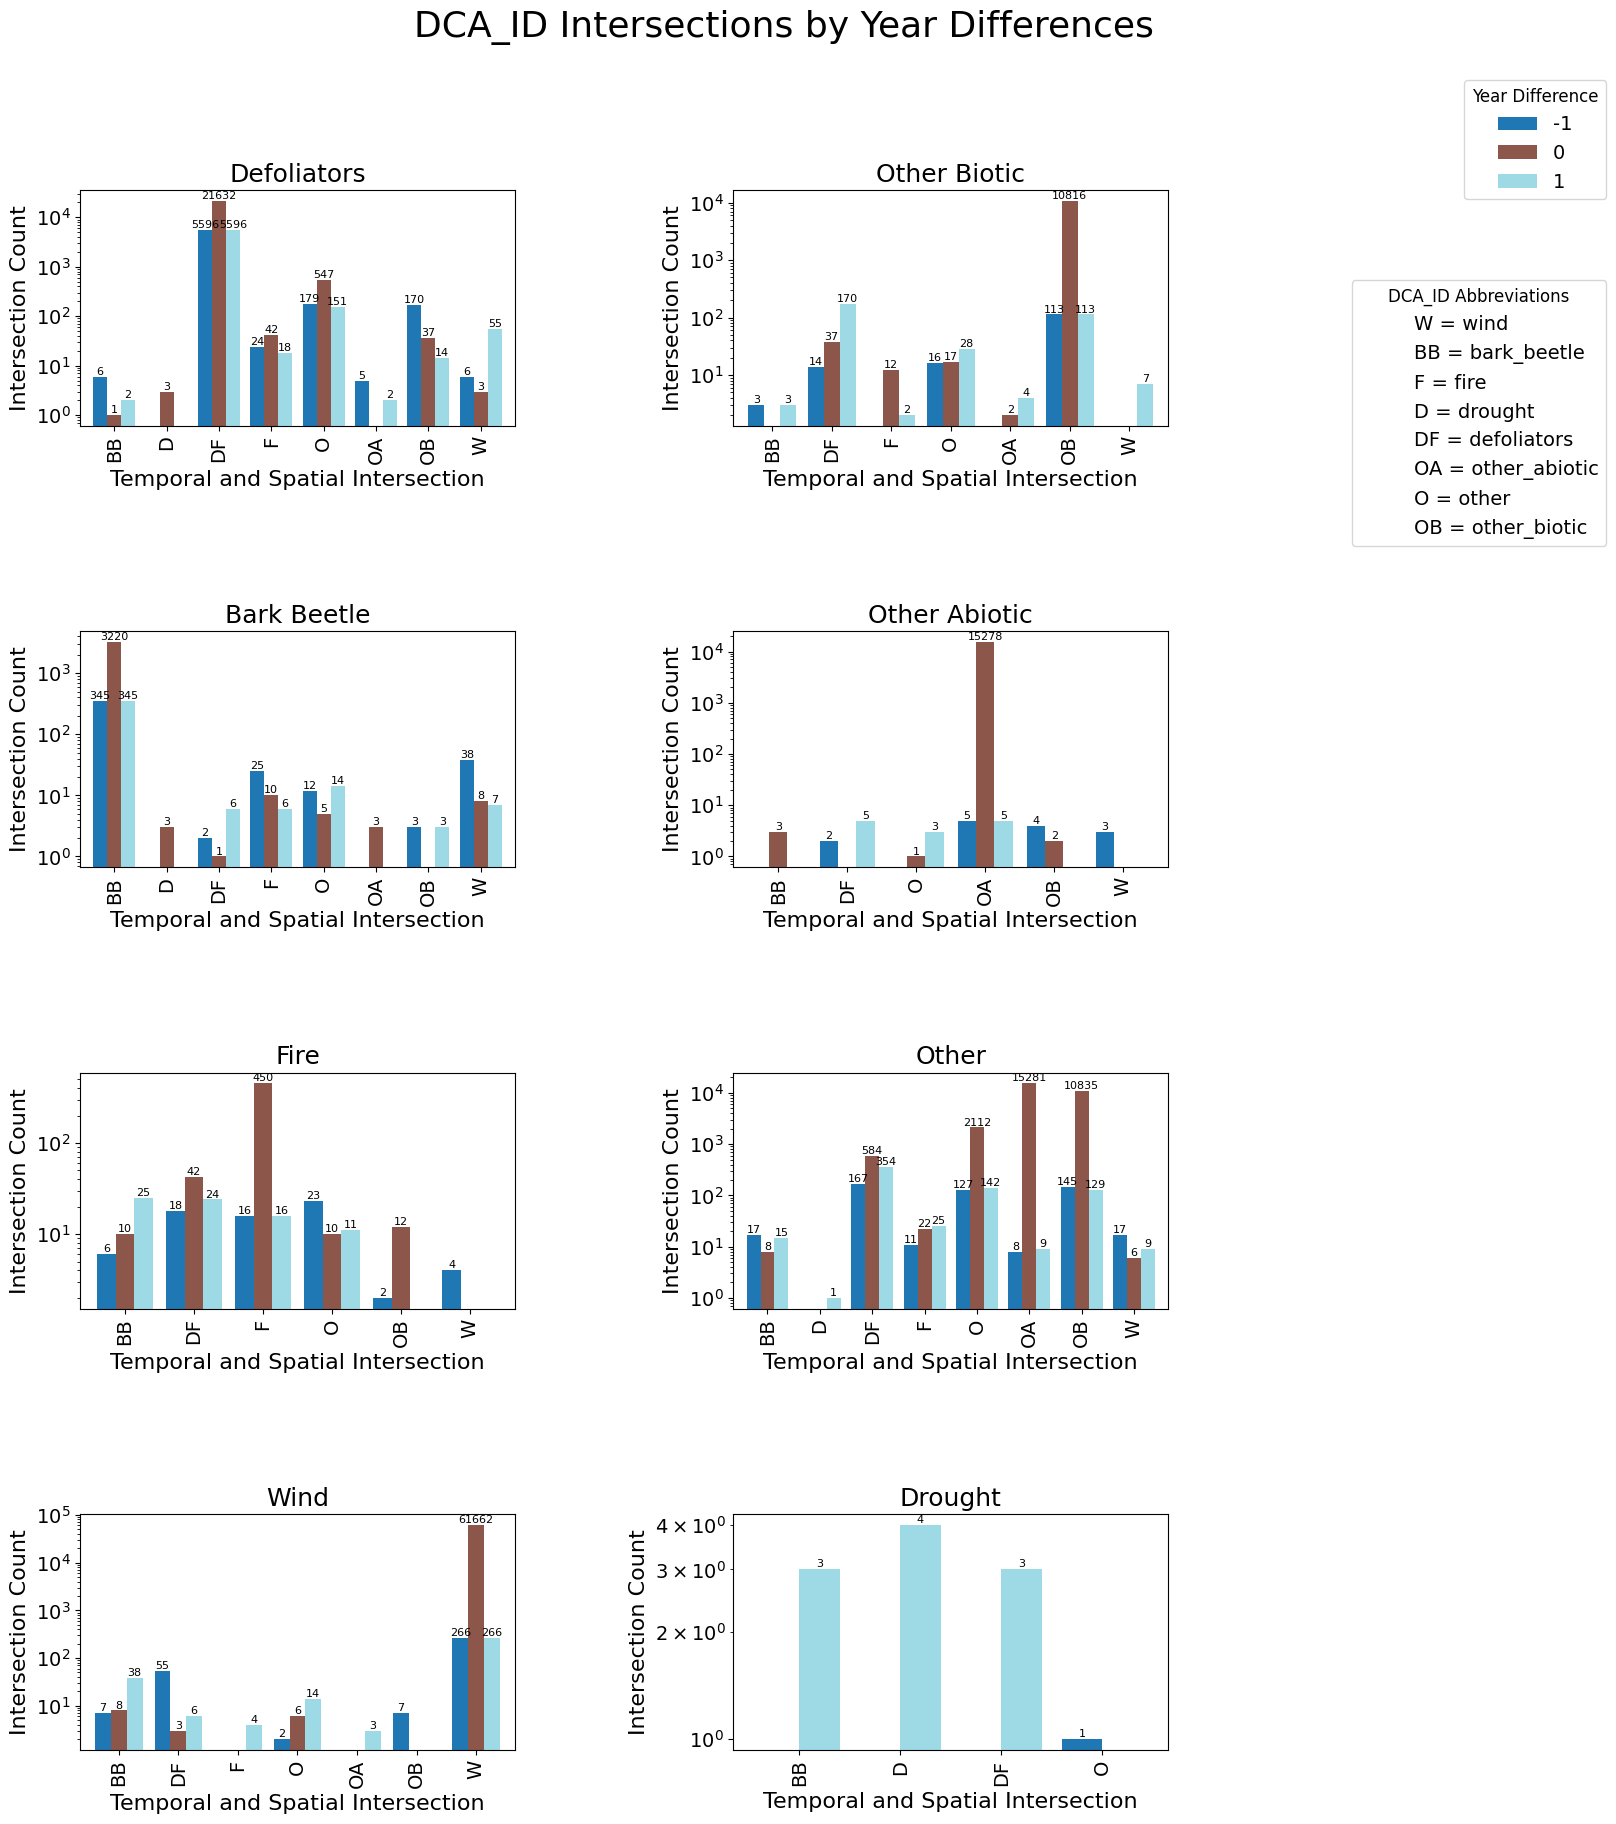

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_dca_id_intersections_years_2_columns(df):
    """
    Plot how often each DCA_ID intersects with other DCA_IDs and itself, grouped by year differences.
    
    Parameters:
    df (DataFrame): DataFrame containing the overlap analysis with 'original_dca_id', 'DCA_ID', 'Year_Diff', and 'Count'.
    """
    # Define the mapping for DCA_IDs
    dca_id_mapping = {
        'wind': 'W',
        'bark_beetle': 'BB',
        'fire': 'F',
        'drought': 'D',
        'defoliators': 'DF',
        'other_abiotic': 'OA',
        'other': 'O',
        'other_biotic': 'OB'
    }
    
    # Reverse mapping for the legend
    reverse_mapping = {v: k for k, v in dca_id_mapping.items()}
    
    # Map DCA_ID to short forms
    df['DCA_ID_short'] = df['DCA_ID'].map(dca_id_mapping)
    
    # Get unique DCA_IDs
    unique_dca_ids = df['original_dca_id'].unique()
    
    # Create a figure with subplots
    num_dca_ids = len(unique_dca_ids)
    cols = 2  # Number of columns in the subplot grid
    rows = (num_dca_ids + cols - 1) // cols  # Compute the number of rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    
    # Adjust subplot spacing globally
    fig.subplots_adjust(left=0.05, right=0.75, bottom=0.1, top=0.9, wspace=0.4, hspace=0.6)

    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    all_handles, all_labels = [], []  # To collect handles and labels for the legend from the first subplot
    
    for i, target_dca_id in enumerate(unique_dca_ids):
        # Filter the DataFrame for the current original_dca_id
        filtered_df = df[df['original_dca_id'] == target_dca_id]
        
        # Pivot the DataFrame for plotting with short DCA_IDs
        pivot_df = filtered_df.pivot_table(index='DCA_ID_short', columns='Year_Diff', values='Count', fill_value=0)
        
        # Plot the results on the correct subplot axis
        ax = axes[i]
        bars = pivot_df.plot(kind='bar', ax=ax, colormap='tab20', width=0.8, legend=False)
        
        # Extract legend handles and labels only from the first subplot
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            all_handles = handles
            all_labels = labels
        
        # Add the count numbers above the bars
        for c in ax.containers:
            ax.bar_label(c, label_type='edge', fontsize=8)

        ax.set_xlabel('Temporal and Spatial Intersection')
        ax.set_ylabel('Intersection Count')
        ax.set_title(f'{format_label(target_dca_id)}')
        ax.set_yscale('log')
        ax.set_xticklabels(pivot_df.index)  # Set x-tick labels directly
        
        # Adjust position of each subplot for more buffer
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.01, pos.y0 + 0.01, pos.width - 0.02, pos.height - 0.02])
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Add the primary legend from the first subplot
    legend1 = fig.legend(all_handles, all_labels, title='Year Difference', loc='upper right', bbox_to_anchor=(1.02, 0.95))
    plt.setp(legend1.get_title(), fontsize=12)  # Set font size for the legend title

    # Create a dummy plot to generate the second legend
    for label, name in reverse_mapping.items():
        axes[0].bar(0, 0, color='none', label=f"{label} = {name}")

    # Add the secondary legend for the DCA_ID abbreviations
    legend2 = fig.legend(handles=axes[0].get_legend_handles_labels()[0][-len(reverse_mapping):],
                         labels=[f"{abbr} = {name}" for abbr, name in reverse_mapping.items()],
                         title='DCA_ID Abbreviations',
                         loc='upper right',
                         bbox_to_anchor=(1.02, 0.85))
    plt.setp(legend2.get_title(), fontsize=12)  # Set font size for the legend title

    # Add a header to the entire plot
    fig.suptitle('DCA_ID Intersections by Year Differences', fontsize=26)
    plt.savefig('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/DCA_ID_Intersections_by_Year_Differences_vertical.png', dpi=300, bbox_inches='tight')

    plt.show()

# Example usage:
plot_all_dca_id_intersections_years_2_columns(res)


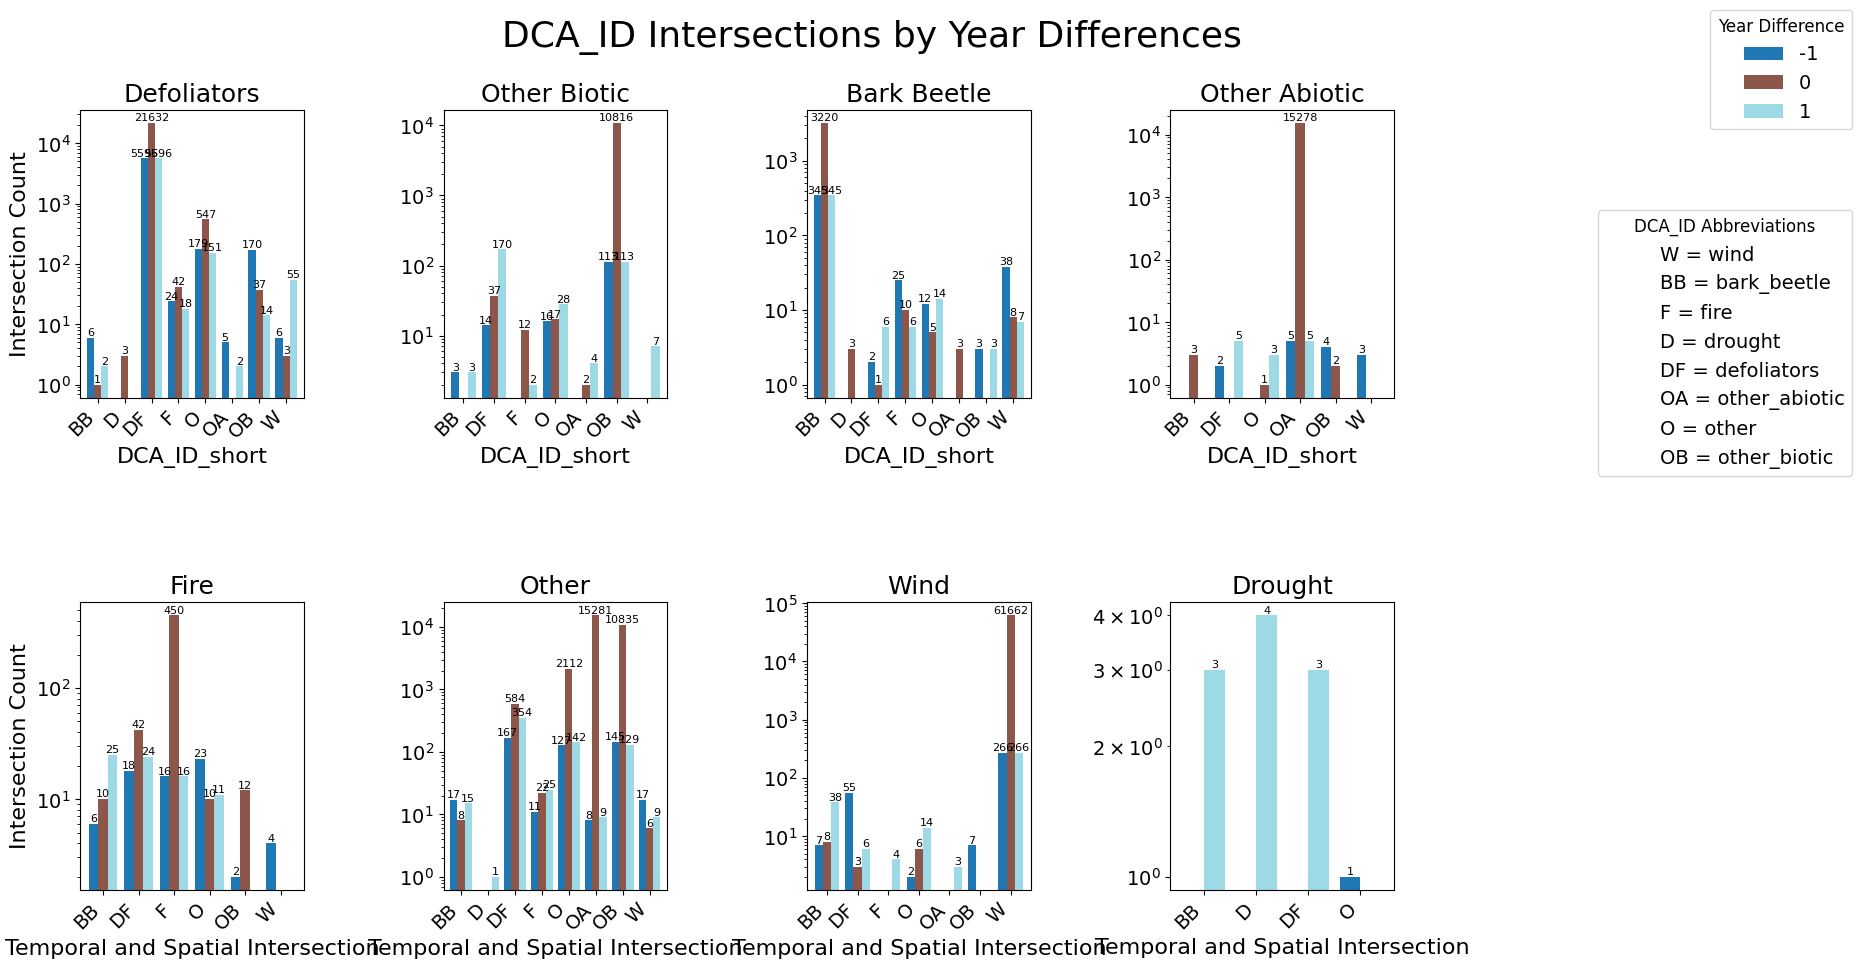

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_dca_id_intersections_years(df):
    """
    Plot how often each DCA_ID intersects with other DCA_IDs and itself, grouped by year differences.
    
    Parameters:
    df (DataFrame): DataFrame containing the overlap analysis with 'original_dca_id', 'DCA_ID', 'Year_Diff', and 'Count'.
    """
    # Define the mapping for DCA_IDs
    dca_id_mapping = {
        'wind': 'W',
        'bark_beetle': 'BB',
        'fire': 'F',
        'drought': 'D',
        'defoliators': 'DF',
        'other_abiotic': 'OA',
        'other': 'O',
        'other_biotic': 'OB'
    }
    
    # Reverse mapping for the legend
    reverse_mapping = {v: k for k, v in dca_id_mapping.items()}
    
    # Map DCA_ID to short forms
    df['DCA_ID_short'] = df['DCA_ID'].map(dca_id_mapping)
    
    # Get unique DCA_IDs
    unique_dca_ids = df['original_dca_id'].unique()
    
    # Create a figure with subplots
    num_dca_ids = len(unique_dca_ids)
    cols = 4  # Number of columns in the subplot grid
    rows = (num_dca_ids + cols - 1) // cols  # Compute the number of rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    
    # Adjust subplot spacing globally
    fig.subplots_adjust(left=0.05, right=0.8, bottom=0.1, top=0.9, wspace=0.4, hspace=0.6)

    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    all_handles, all_labels = [], []  # To collect handles and labels for the legend from the first subplot
    
    for i, target_dca_id in enumerate(unique_dca_ids):
        # Filter the DataFrame for the current original_dca_id
        filtered_df = df[df['original_dca_id'] == target_dca_id]
        
        # Pivot the DataFrame for plotting with short DCA_IDs
        pivot_df = filtered_df.pivot_table(index='DCA_ID_short', columns='Year_Diff', values='Count', fill_value=0)
        
        # Plot the results on the correct subplot axis
        ax = axes[i]
        bars = pivot_df.plot(kind='bar', ax=ax, colormap='tab20', width=0.8, legend=False)
        
        # Extract legend handles and labels only from the first subplot
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            all_handles = handles
            all_labels = labels
        
        # Add the count numbers above the bars
        for c in ax.containers:
            ax.bar_label(c, label_type='edge', fontsize=8)

        # Set axis labels only once per row and adjust position for better readability
        if i // cols == (rows - 1):
            ax.set_xlabel('Temporal and Spatial Intersection')
        if i % cols == 0:
            ax.set_ylabel('Intersection Count')

        ax.set_title(f'{format_label(target_dca_id)}')
        ax.set_yscale('log')
        ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')  # Rotate x-tick labels
        
        # Adjust position of each subplot for more buffer
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.01, pos.y0 + 0.01, pos.width - 0.02, pos.height - 0.02])
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Add the primary legend from the first subplot
    legend1 = fig.legend(all_handles, all_labels, title='Year Difference', loc='upper right', bbox_to_anchor=(1.05, 1.0))
    plt.setp(legend1.get_title(), fontsize=12)  # Set font size for the legend title

    # Create a dummy plot to generate the second legend
    dummy_ax = axes[0]  # Use the first subplot's axis for the dummy plot
    for label, name in reverse_mapping.items():
        dummy_ax.bar(0, 0, color='none', label=f"{label} = {name}")

    # Add the secondary legend for the DCA_ID abbreviations
    legend2 = fig.legend(handles=dummy_ax.get_legend_handles_labels()[0][-len(reverse_mapping):],
                         labels=[f"{abbr} = {name}" for abbr, name in reverse_mapping.items()],
                         title='DCA_ID Abbreviations',
                         loc='upper right',
                         bbox_to_anchor=(1.05, 0.8))
    plt.setp(legend2.get_title(), fontsize=12)  # Set font size for the legend title

    # Add a header to the entire plot
    fig.suptitle('DCA_ID Intersections by Year Differences', fontsize=26)
    plt.savefig('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/DCA_ID_Intersections_by_Year_Differences.png', dpi=300, bbox_inches='tight')

    plt.show()

# Example usage:
plot_all_dca_id_intersections_years(res)


In [ ]:

# Pivot the DataFrame for better plotting
pivot_df = intersection_df.pivot(index='DCA_ID', columns='Year_Diff', values='Count').fillna(0)

# Plot the results as a grouped bar plot
ax = pivot_df.plot(kind='bar', figsize=(14, 8), colormap='tab20', width=0.8)

# Create legend mapping for plot
legend_labels = {code: f"{desc} ({code})" for desc, code in dca_id_mapping.items() if code in pivot_df.columns}

# Add the count numbers above the bars
for c in ax.containers:
    ax.bar_label(c, label_type='edge', fontsize=10)

plt.xlabel('Year Difference')
plt.ylabel('Intersection Count')
plt.title(f'Intersections with {target_dca_id} by Year Difference')
plt.xticks(rotation=45, ha='right')
plt.legend(title='DCA_ID Codes', labels=[legend_labels.get(label, label) for label in pivot_df.columns], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [62]:
result_df

,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O,Longest_Duration,DCA_ID_Count,DCA_ID_List
0,0,defoliators,1999,"MULTIPOLYGON (((-90.76738 29.90510, -90.77827 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,"[62, 2933, 3310, 3331, 11782, 12851, 13173, 17...",3,10,"[defoliators, defoliators, defoliators, defoli..."
4,4,defoliators,1998,"MULTIPOLYGON (((-91.25619 30.06854, -91.25474 ...",8,Defoliation,1,12021,2,NaN,baldcypress,221.0,4,"[55, 66, 9393, 10979, 11355, 12854, 13220, 140...",2,9,"[defoliators, defoliators, defoliators, defoli..."
5,5,defoliators,1998,"MULTIPOLYGON (((-90.76337 30.18860, -90.76184 ...",8,Defoliation,1,12021,2,NaN,baldcypress,221.0,0,"[56, 3137, 3870, 10471, 11951, 12817, 14691, 1...",2,11,"[defoliators, defoliators, defoliators, defoli..."
7,7,other_biotic,1999,"MULTIPOLYGON (((-79.93646 38.11799, -79.93576 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,6,"[10, 10061, 19832, 20403]",1,4,"[defoliators, defoliators, defoliators, defoli..."
9,9,defoliators,1998,"MULTIPOLYGON (((-90.74140 30.23026, -90.74057 ...",8,Defoliation,1,12096,2,NaN,water tupelo,691.0,0,"[28, 3137, 3881, 4280, 5185, 10581, 14069, 153...",2,10,"[defoliators, defoliators, defoliators, defoli..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68911,68929,wind,2022,"MULTIPOLYGON (((-81.77619 26.94044, -81.77583 ...",8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21428,"[68546, 68729, 68866]",1,3,"[wind, wind, wind]"
68912,68930,wind,2022,"MULTIPOLYGON (((-81.76396 26.94097, -81.76360 ...",8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21428,"[67265, 68366, 68391, 68555, 68825, 68881]",1,6,"[wind, wind, wind, wind, wind, wind]"
68913,68931,wind,2022,"MULTIPOLYGON (((-81.96957 27.07910, -81.96922 ...",8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),All tree species,9998.0,21465,"[67347, 68238, 68250, 68499]",1,4,"[wind, wind, wind, wind]"
68914,68932,wind,2022,"MULTIPOLYGON (((-81.81675 27.04737, -81.81640 ...",8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21451,"[68214, 68647, 68687, 68694, 68708]",1,5,"[wind, wind, wind, wind, wind]"


In [49]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_dca_id_intersections(gdf_overlap, target_dca_id):
    """
    Plot how often a specific DCA_ID (e.g., bark_beetle) intersects with other DCA_IDs and itself.

    Parameters:
    gdf_overlap (DataFrame): DataFrame containing the overlap analysis with 'DCA_ID_List'.
    target_dca_id (str): The DCA_ID of interest (e.g., 'bark_beetle').
    """
    # Filter the DataFrame to include only rows where the target_dca_id is in 'DCA_ID_List'
    filtered_df = gdf_overlap[gdf_overlap['DCA_ID_List'].apply(lambda x: target_dca_id in x)]
    
    # Create a dictionary to store the counts of intersections
    intersection_counts = {}
    
    # Iterate over each filtered row
    for _, row in filtered_df.iterrows():
        dca_ids = row['DCA_ID_List']
        # Count how often each DCA_ID intersects with the target_dca_id
        for dca_id in dca_ids:
            if dca_id in intersection_counts:
                intersection_counts[dca_id] += 1
            else:
                intersection_counts[dca_id] = 1
    
    # Convert the intersection counts to a DataFrame for plotting
    intersection_df = pd.DataFrame(list(intersection_counts.items()), columns=['DCA_ID', 'Count'])
    
    # Sort by count for better visualization
    intersection_df = intersection_df.sort_values(by='Count', ascending=False)
    
    # Plot the results as a bar plot
    plt.figure(figsize=(12, 8))
    bars = plt.bar(intersection_df['DCA_ID'], intersection_df['Count'], color='skyblue')
    
    # Add the count numbers above the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=10)
    
    plt.xlabel('DCA_ID')
    plt.ylabel('Intersection Count')
    plt.title(f'Intersections with {target_dca_id}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

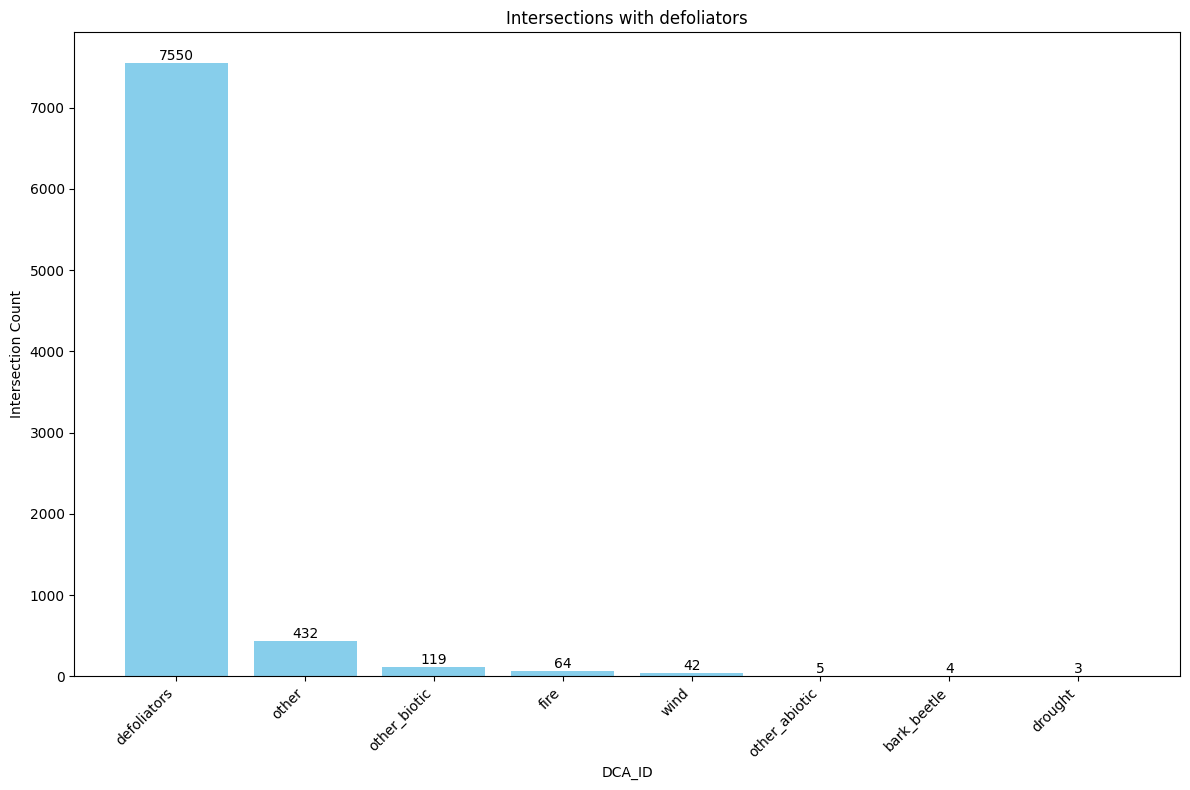

In [50]:
# Example usage:
plot_dca_id_intersections(gdf_overlap, target_dca_id='defoliators')

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_dca_id_intersections(gdf_overlap):
    """
    Plot how often each DCA_ID intersects with other DCA_IDs and itself.
    
    Parameters:
    gdf_overlap (DataFrame): DataFrame containing the overlap analysis with 'DCA_ID_List'.
    """
    # Get unique DCA_IDs
    unique_dca_ids = gdf_overlap['DCA_ID_List'].explode().unique()
    
    # Create a figure with subplots
    num_dca_ids = len(unique_dca_ids)
    cols = 4  # Number of columns in the subplot grid
    rows = (num_dca_ids + cols - 1) // cols  # Compute the number of rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), constrained_layout=True)
    
    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    for i, target_dca_id in enumerate(unique_dca_ids):
        # Filter the DataFrame to include only rows where the target_dca_id is in 'DCA_ID_List'
        filtered_df = gdf_overlap[gdf_overlap['DCA_ID_List'].apply(lambda x: target_dca_id in x)]
        
        # Create a dictionary to store the counts of intersections
        intersection_counts = {}
        
        # Iterate over each filtered row
        for _, row in filtered_df.iterrows():
            dca_ids = row['DCA_ID_List']
            # Count how often each DCA_ID intersects with the target_dca_id
            for dca_id in dca_ids:
                if dca_id in intersection_counts:
                    intersection_counts[dca_id] += 1
                else:
                    intersection_counts[dca_id] = 1
        
        # Convert the intersection counts to a DataFrame for plotting
        intersection_df = pd.DataFrame(list(intersection_counts.items()), columns=['DCA_ID', 'Count'])
        
        # Sort by count for better visualization
        intersection_df = intersection_df.sort_values(by='Count', ascending=False)
        
        # Plot the results as a bar plot in the current subplot
        ax = axes[i]
        bars = ax.bar(intersection_df['DCA_ID'], intersection_df['Count'], color='skyblue')
        
        # Add the count numbers above the bars
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=10)
        
        ax.set_xlabel('DCA_ID')
        ax.set_ylabel('Intersection Count')
        ax.set_title(f'{target_dca_id}')
        ax.set_xticklabels(intersection_df['DCA_ID'], rotation=45, ha='right')

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.show()


/tmp/ipykernel_2557826/2848441712.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(intersection_df['DCA_ID'], rotation=45, ha='right')
/tmp/ipykernel_2557826/2848441712.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(intersection_df['DCA_ID'], rotation=45, ha='right')
/tmp/ipykernel_2557826/2848441712.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(intersection_df['DCA_ID'], rotation=45, ha='right')
/tmp/ipykernel_2557826/2848441712.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(intersection_df['DCA_ID'], rotation=45, ha='right')
/tmp/ipykernel_2557826/2848441712.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(intersection_df['DCA_ID'], rotation=45, ha='right')
/tmp/ipykernel_2557826/2848441712.py:58: UserWarning: F

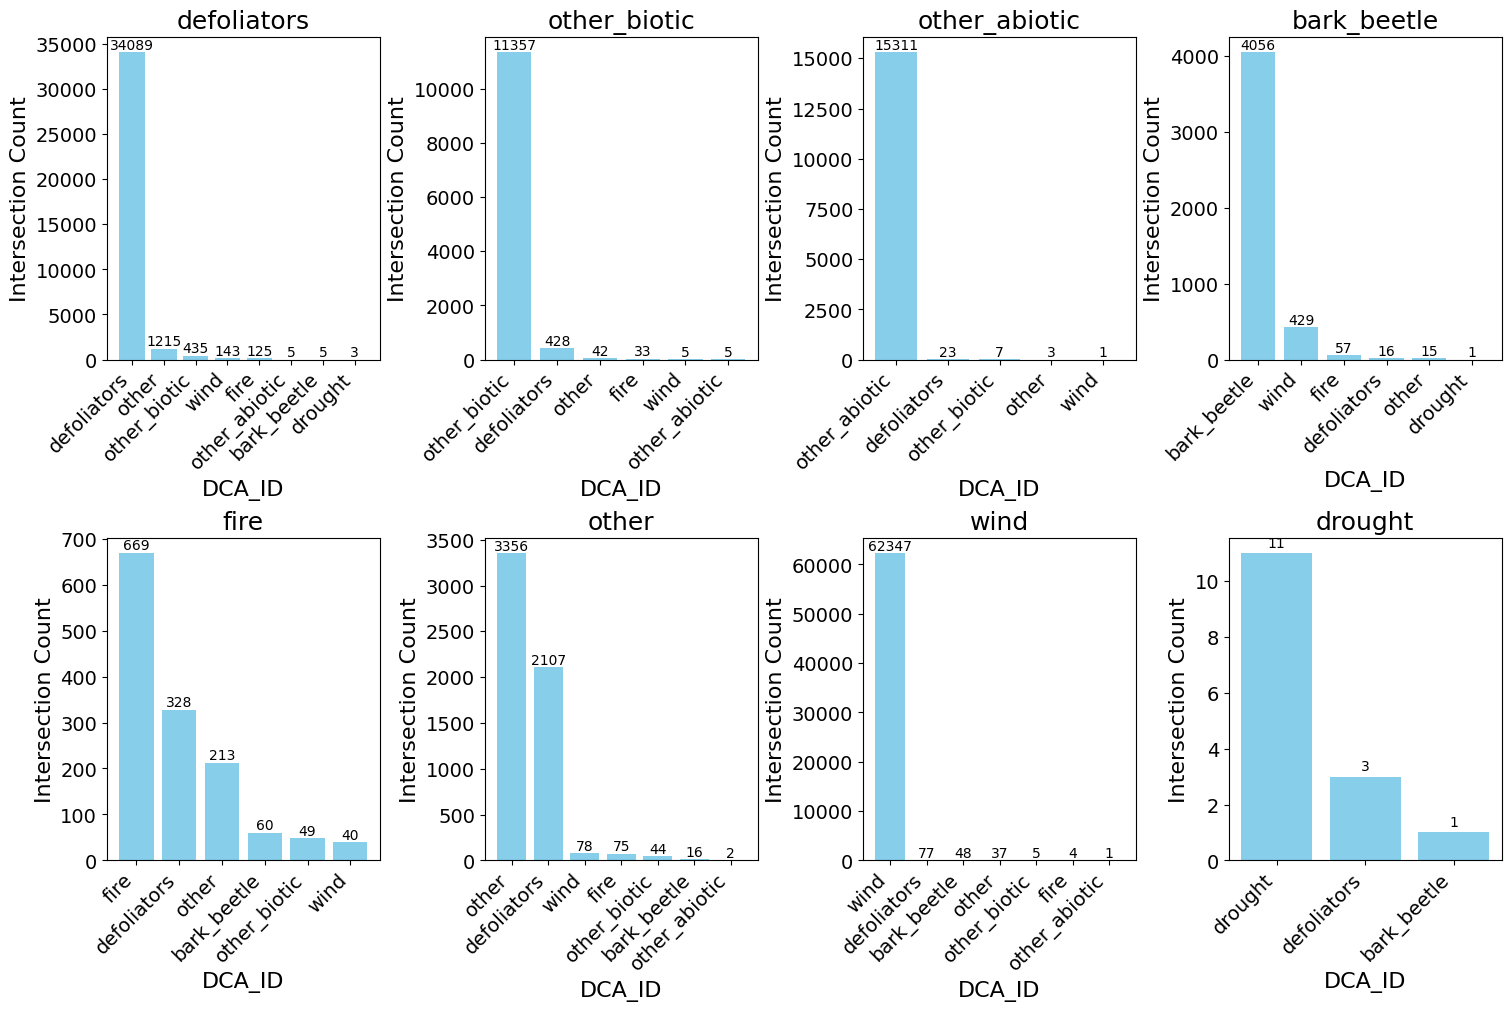

In [63]:
plot_all_dca_id_intersections(gdf_overlap)

# Code for generating final table

In [54]:
def load_data(path):
    # Step 1: Read the CSV file into a DataFrame
    df = pd.read_csv(input_file)

    # Step 2: Convert the WKT geometries to Shapely geometries
    df['geometry'] = df['geometry'].apply(wkt.loads)

    # Step 3: Convert the DataFrame to a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry='geometry')
    gdf = gdf.rename(columns={'Unnamed: 0': 'ID_E'})

    # Set the coordinate reference system (CRS) if it's not already set
    gdf.set_crs(epsg=4326, inplace=True)

    return gdf

In [55]:
import pandas as pd
from tqdm import tqdm

def keep_overlapping_entries(df, id_col='ID_E', year_col='SURVEY_YEAR', geometry_col='geometry'):
    """
    Keep entries that overlap spatially within a ±1 year temporal window 
    and add a column 'ID_O' containing the IDs of overlapping elements.

    Parameters:
    df (DataFrame): DataFrame containing the data.
    id_col (str): Name of the column containing unique IDs (e.g., 'ID_E').
    year_col (str): Name of the column containing the survey year.
    geometry_col (str): Name of the column containing geometry data.

    Returns:
    DataFrame: DataFrame with overlapping entries and a new column 'ID_O' listing overlapping IDs.
    """
    df = df.copy()
    df['ID_O'] = None  # Initialize the ID_O column
    
    # Iterate over each row to check for overlaps with a progress bar
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Checking overlaps"):
        year = row[year_col]
        geom = row[geometry_col]
        id_e = row[id_col]
        
        # Define the time window for overlap check within ±1 year
        time_window = (df[year_col] >= (year - 1)) & (df[year_col] <= (year + 1))

        # Check for spatial overlaps within the time window
        spatial_overlaps = df.loc[time_window & df[geometry_col].intersects(geom)]

        # Exclude the current row from the overlaps
        spatial_overlaps = spatial_overlaps[spatial_overlaps[id_col] != id_e]

        # If overlaps are found, update the ID_O column
        if not spatial_overlaps.empty:
            df.at[i, 'ID_O'] = spatial_overlaps[id_col].tolist()

    # Return only the rows where there is an overlap (ID_O is not None)
    return df.dropna(subset=['ID_O'])


In [56]:
def remove_overlapping_entries(df, year_col='SURVEY_YEAR', geometry_col='geometry'):
    """
    Remove entries that overlap spatially within a given temporal window.

    Parameters:
    df (DataFrame): DataFrame containing the data.
    year_col (str): Name of the column containing the survey year.
    geometry_col (str): Name of the column containing geometry data.

    Returns:
    DataFrame: DataFrame with overlapping entries removed.
    """
    df = df.copy()
    overlaps = set()
    df['ID_O'] = None  # Initialize the ID_O column

    # Iterate over each row to check for overlaps with a progress bar
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Checking overlaps"):
        year = row[year_col]
        geom = row[geometry_col]

        # Define the time window for overlap check
        #time_window = (df[year_col] >= (year - 10)) & (df[year_col] <= (year + 5))
        time_window = (df[year_col] >= (year - 5)) & (df[year_col] <= (year + 5))

        # Check for spatial overlaps within the time window
        #spatial_overlaps = df[time_window][df[geometry_col].intersects(geom)]
        spatial_overlaps = df.loc[time_window & df[geometry_col].intersects(geom)]
        
        # Add the indices of the overlapping rows to the overlaps set
        if len(spatial_overlaps) > 1:
            overlaps.add(i)
            overlaps.update(spatial_overlaps.index)

    # Drop the overlapping rows
    df = df.drop(index=overlaps)
    return df

In [57]:
import pandas as pd
from tqdm import tqdm

def analyze_overlaps(gdf_overlap, id_col='ID_E', year_col='SURVEY_YEAR', dca_id_col='DCA_ID'):
    """
    Analyze overlaps to find the longest duration between overlapping entries
    and count the unique DCA_IDs.

    Parameters:
    gdf_overlap (DataFrame): DataFrame containing overlapping entries.
    id_col (str): Name of the column containing unique IDs (e.g., 'ID_E').
    year_col (str): Name of the column containing the survey year.
    dca_id_col (str): Name of the column containing the DCA_ID.
    
    Returns:
    DataFrame: DataFrame with additional columns for longest duration, DCA_ID count, and the list of DCA_IDs.
    """
    # Initialize columns to store the results
    gdf_overlap['Longest_Duration'] = None
    gdf_overlap['DCA_ID_Count'] = None
    gdf_overlap['DCA_ID_List'] = None

    # Iterate over each row with overlaps
    for i, row in tqdm(gdf_overlap.iterrows(), total=gdf_overlap.shape[0], desc="Analyzing overlaps"):
        
        overlap_ids = row['ID_O']
        
        if overlap_ids:
            # Find the rows in the original DataFrame that correspond to these overlap IDs
            overlap_rows = gdf_overlap[gdf_overlap[id_col].isin(overlap_ids)]
            
            # Calculate the longest duration (max year - min year)
            min_year = overlap_rows[year_col].min()
            max_year = overlap_rows[year_col].max()
            longest_duration = max_year - min_year +1
            
            # Get the unique DCA_IDs and their count
            dca_id_list = overlap_rows[dca_id_col].tolist()
            dca_id_count = len(dca_id_list)
            
            # Store the results back in the DataFrame
            gdf_overlap.at[i, 'Longest_Duration'] = longest_duration
            gdf_overlap.at[i, 'DCA_ID_Count'] = dca_id_count
            gdf_overlap.at[i, 'DCA_ID_List'] = dca_id_list

    return gdf_overlap

In [58]:
def add_dca_id_year_info(exploded_df):
    """
    Add the DCA_ID and Year information for each ID_O from the original_gdf DataFrame.

    Parameters:
    exploded_df (DataFrame): DataFrame with exploded 'ID_O' list.
    original_gdf (DataFrame): Original DataFrame containing 'USDA_IDX', 'SURVEY_YEAR', and 'DCA_ID'.

    Returns:
    DataFrame: Updated DataFrame with 'O_Year' and 'O_DCA_ID' columns.
    """
    # Create dictionaries for fast lookups
    id_to_year = exploded_df.set_index('ID_E')['SURVEY_YEAR'].to_dict()
    id_to_dca = exploded_df.set_index('ID_E')['DCA_ID'].to_dict()

    # Map the 'ID_O' column to the corresponding year using id_to_year and convert it to integers
    exploded_df['O_Year'] = exploded_df['ID_O'].map(id_to_year)
    exploded_df['O_DCA_ID'] = exploded_df['ID_O'].map(id_to_dca)

    # Convert non-null values to integers and replace NaN with None
    exploded_df['O_Year'] = exploded_df['O_Year'].apply(lambda x: int(x) if pd.notna(x) else 10)
    # Replace 10 with None in the O_Year column
    exploded_df['O_Year'] = exploded_df['O_Year'].replace(10, None)

    # Calculate the year difference
    exploded_df['O_Year_diff'] = (exploded_df['O_Year'] - exploded_df['SURVEY_YEAR'])
    
    # Convert non-null values to integers and replace NaN with None
    exploded_df['O_Year_diff'] = exploded_df['O_Year_diff'].apply(lambda x: int(x) if pd.notna(x) else 10)
    # Replace 10 with None in the O_Year column
    exploded_df['O_Year_diff'] = exploded_df['O_Year_diff'].replace(10, None)

    
    return exploded_df

In [59]:
input_file = "/Net/Groups/BGI/work_2/ForExD/USDA/tables/CONUS_Region8_dissolved.csv"
gdf = load_data(input_file)
print("Step 1: Loading CSV file...")
print(f"Number of elements: {len(gdf)}")

print("Step 2: Removing temporal and spatial overlaps...")
gdf_no_overlap = remove_overlapping_entries(gdf)
print(f"Number of elements after removing temporal and spatial overlaps: {len(gdf_no_overlap)}")

print("Step 3: Checking for temporal and spatial overlaps +- 1 years...")
gdf_overlap = keep_overlapping_entries(gdf)
print(f"Number of elements with temporal and spatial overlaps: {len(gdf_overlap)}")

print("Step 4: Merging the 2 datasets together")
# Assuming gdf_no_overlap and gdf_overlap are your GeoDataFrames
merged_gdf = gpd.GeoDataFrame(pd.concat([gdf_no_overlap, gdf_overlap], ignore_index=True))
merged_gdf

Step 1: Loading CSV file...
Number of elements: 68916
Step 2: Removing temporal and spatial overlaps...


Checking overlaps: 100%|██████████| 68916/68916 [15:39<00:00, 73.36it/s]


Number of elements after removing temporal and spatial overlaps: 36608
Step 3: Checking for temporal and spatial overlaps +- 1 years...


Checking overlaps: 100%|██████████| 68916/68916 [18:29<00:00, 62.10it/s]

Number of elements with temporal and spatial overlaps: 29951
Step 4: Merging the 2 datasets together


,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O
0,2,other_biotic,1999,"MULTIPOLYGON (((-79.76983 37.82674, -79.76868 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,2,None
1,3,other_biotic,1999,"MULTIPOLYGON (((-79.23697 38.09256, -79.23580 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,3,None
2,6,defoliators,2000,"MULTIPOLYGON (((-78.08125 38.86800, -78.08370 ...",8,Defoliation,1,12089,2,NaN,NaN,-1.0,5,None
3,8,other_biotic,1999,"MULTIPOLYGON (((-79.13142 38.15008, -79.13119 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,7,None
4,12,bark_beetle,1998,"MULTIPOLYGON (((-84.97029 32.10620, -84.97032 ...",8,Mortality,2,11003,1,NaN,NaN,-1.0,8,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66554,68929,wind,2022,"MULTIPOLYGON (((-81.77619 26.94044, -81.77583 ...",8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21428,"[68546, 68729, 68866]"
66555,68930,wind,2022,"MULTIPOLYGON (((-81.76396 26.94097, -81.76360 ...",8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21428,"[67265, 68366, 68391, 68555, 68825, 68881]"
66556,68931,wind,2022,"MULTIPOLYGON (((-81.96957 27.07910, -81.96922 ...",8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),All tree species,9998.0,21465,"[67347, 68238, 68250, 68499]"
66557,68932,wind,2022,"MULTIPOLYGON (((-81.81675 27.04737, -81.81640 ...",8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21451,"[68214, 68647, 68687, 68694, 68708]"


In [97]:
result_df = analyze_overlaps(merged_gdf)
exploded_df = result_df.explode('ID_O')
exploded_df = exploded_df.drop(columns=['Longest_Duration', 'DCA_ID_Count', 'DCA_ID_List'])
enriched_df = add_dca_id_year_info(exploded_df)
enriched_df

Analyzing overlaps:   0%|          | 0/66559 [00:00<?, ?it/s]

Analyzing overlaps: 100%|██████████| 66559/66559 [01:44<00:00, 635.06it/s]  


,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O,O_Year,O_DCA_ID,O_Year_diff
0,2,other_biotic,1999,"MULTIPOLYGON (((-79.76983 37.82674, -79.76868 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,2,None,None,NaN,None
1,3,other_biotic,1999,"MULTIPOLYGON (((-79.23697 38.09256, -79.23580 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,3,None,None,NaN,None
2,6,defoliators,2000,"MULTIPOLYGON (((-78.08125 38.86800, -78.08370 ...",8,Defoliation,1,12089,2,NaN,NaN,-1.0,5,None,None,NaN,None
3,8,other_biotic,1999,"MULTIPOLYGON (((-79.13142 38.15008, -79.13119 ...",8,Crown Dieback,4,13012,64,NaN,NaN,-1.0,7,None,None,NaN,None
4,12,bark_beetle,1998,"MULTIPOLYGON (((-84.97029 32.10620, -84.97032 ...",8,Mortality,2,11003,1,NaN,NaN,-1.0,8,None,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66558,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67505,2022,bark_beetle,0
66558,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67510,2022,bark_beetle,0
66558,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67511,2022,bark_beetle,0
66558,68933,bark_beetle,2022,"MULTIPOLYGON (((-81.72431 27.33876, -81.72395 ...",8,Mortality,2,11003,1,Light (4-10%),NaN,NaN,21478,67974,2022,bark_beetle,0


In [98]:
# Calculate the number of unique 'ID_E' values
unique_id_e_count = gdf_no_overlap['ID_E'].nunique()
print(f"Number of unique 'ID_E' that have no overlaps in the +-5 years: {unique_id_e_count}")
# Calculate the number of unique 'ID_E' values
unique_id_e_count = gdf_overlap['ID_E'].nunique()
print(f"Number of unique 'ID_E' overlapping events in the -+1 years: {unique_id_e_count}\n")

# Calculate the number of unique 'ID_E' values
unique_id_e_count = enriched_df['ID_E'].unique()
print(f"Number of unique 'ID_E': {unique_id_e_count}")

# Save the GeoDataFrame to a shapefile
#enriched_df.to_file('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/refdm_with_overlaps_and_no_overlaps.shp')

Number of unique 'ID_E' that have no overlaps in the +-5 years: 36608
Number of unique 'ID_E' overlapping events in the -+1 years: 29951

Number of unique 'ID_E': [    2     3     6 ... 68931 68932 68933]


/tmp/ipykernel_3429778/720441343.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]
/tmp/ipykernel_3429778/720441343.py:11: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]  # Adjust this line as needed to select region 8


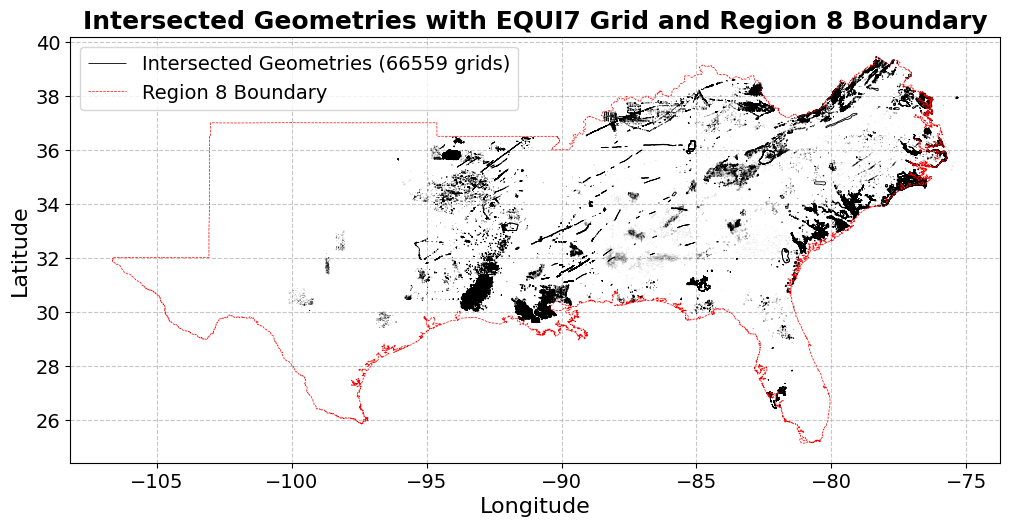

In [99]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Define a POLYGON geometry
usa_filepath = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
usa = gpd.read_file(usa_filepath)
country = usa[usa.REGION == "08"]
region = country.explode()[0:1]

# Example data for region 8
region = country.explode()[0:1]  # Adjust this line as needed to select region 8
# Plot the boundary of the intersected geometries and region 8 with enhancements
fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

# Plot the boundaries of intersected_gdf
enriched_df.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)
unique_id_e_count = enriched_df['ID_E'].unique()
# Plot the boundary of region 8
region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

# Customize the plot appearance
ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Set the aspect ratio of the plot to be equal
ax.set_aspect('equal')

# Optional: Add a legend if needed
ax.legend([f'Intersected Geometries ({len(unique_id_e_count)} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

plt.show()


In [100]:
# Step 5: Filter for disturbances recorded between 2016 and 2020
print("Step 5: Filtering disturbances correct recorded between 2016 and 2020...")
gdf_filtered = enriched_df[(enriched_df['SURVEY_YEAR'] > 2016) & (enriched_df['SURVEY_YEAR'] <= 2020)]

# Filter out specific disturbance types
excluded_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
filtered_df = gdf_filtered[~gdf_filtered['DCA_ID'].isin(excluded_types)].copy()

# Calculate the number of unique 'ID_E' values
unique_id_f_count = len(filtered_df['ID_E'].unique())
print(f"Number of unique 'ID_E': {unique_id_f_count}")

filtered_df

Step 5: Filtering disturbances correct recorded between 2016 and 2020...
Number of unique 'ID_E': 18731


,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O,O_Year,O_DCA_ID,O_Year_diff
24325,32095,bark_beetle,2017,"MULTIPOLYGON (((-86.09680 32.14270, -86.09685 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14245,None,None,NaN,None
24326,32096,bark_beetle,2017,"MULTIPOLYGON (((-86.01648 32.01100, -86.01655 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14246,None,None,NaN,None
24327,32097,bark_beetle,2017,"MULTIPOLYGON (((-86.24623 32.06300, -86.24629 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14247,None,None,NaN,None
24328,32098,bark_beetle,2017,"MULTIPOLYGON (((-86.08565 32.05823, -86.08572 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14248,None,None,NaN,None
24329,32099,bark_beetle,2017,"MULTIPOLYGON (((-87.40289 32.86707, -87.40294 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14249,None,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55705,56550,defoliators,2020,"MULTIPOLYGON (((-76.68491 36.30345, -76.70227 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,17163,46455,2019,defoliators,-1
55705,56550,defoliators,2020,"MULTIPOLYGON (((-76.68491 36.30345, -76.70227 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,17163,46456,2019,defoliators,-1
55705,56550,defoliators,2020,"MULTIPOLYGON (((-76.68491 36.30345, -76.70227 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,17163,46462,2019,defoliators,-1
55705,56550,defoliators,2020,"MULTIPOLYGON (((-76.68491 36.30345, -76.70227 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,17163,46464,2019,defoliators,-1


/tmp/ipykernel_3429778/3738560801.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]
/tmp/ipykernel_3429778/3738560801.py:11: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]  # Adjust this line as needed to select region 8


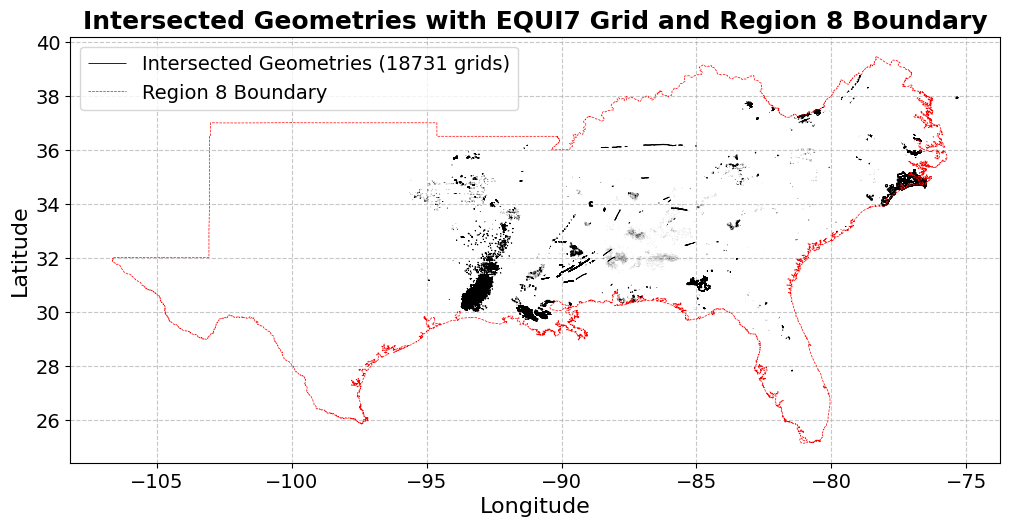

In [101]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Define a POLYGON geometry
usa_filepath = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
usa = gpd.read_file(usa_filepath)
country = usa[usa.REGION == "08"]
region = country.explode()[0:1]

# Example data for region 8
region = country.explode()[0:1]  # Adjust this line as needed to select region 8
# Plot the boundary of the intersected geometries and region 8 with enhancements
fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

# Plot the boundaries of intersected_gdf
filtered_df.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)
unique_id_f_count = len(filtered_df['ID_E'].unique())
# Plot the boundary of region 8
region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

# Customize the plot appearance
ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Set the aspect ratio of the plot to be equal
ax.set_aspect('equal')

# Optional: Add a legend if needed
ax.legend([f'Intersected Geometries ({unique_id_f_count} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

plt.show()


In [102]:
# Step 8: Generate new index_usda values
print("Step 8: Generating new index_usda values...")
filtered_df['index_usda'] = filtered_df.apply(lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1)

# Step 9: Calculating area in km²
print("Step 9: Calculating area in km²")
gdf_with_area = calculate_area_in_km2(filtered_df)

# Step 10: Remove elements larger than 15km²
print("Step 10: Removing elements larger than 15km²")
gdf_area = gdf_with_area[gdf_with_area['area_km2'] <= 15]

# Print the number of remaining elements
print(f"Number of elements after filtering: {len(gdf_area)}")

# Calculate the number of unique 'ID_E' values
unique_id_a_count = len(gdf_area['ID_E'].unique())
print(f"Number of unique 'ID_E': {unique_id_a_count}")

Step 8: Generating new index_usda values...


Step 9: Calculating area in km²
Step 10: Removing elements larger than 15km²
Number of elements after filtering: 65160
Number of unique 'ID_E': 18555


In [103]:
gdf_area

,ID_E,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,ID_O,O_Year,O_DCA_ID,O_Year_diff,index_usda,area_km2
24325,32095,bark_beetle,2017,"MULTIPOLYGON (((-86.09680 32.14270, -86.09685 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14245,None,None,NaN,None,bark_beetle_2017_24325,0.005641
24326,32096,bark_beetle,2017,"MULTIPOLYGON (((-86.01648 32.01100, -86.01655 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14246,None,None,NaN,None,bark_beetle_2017_24326,0.011262
24327,32097,bark_beetle,2017,"MULTIPOLYGON (((-86.24623 32.06300, -86.24629 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14247,None,None,NaN,None,bark_beetle_2017_24327,0.011274
24328,32098,bark_beetle,2017,"MULTIPOLYGON (((-86.08565 32.05823, -86.08572 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14248,None,None,NaN,None,bark_beetle_2017_24328,0.011273
24329,32099,bark_beetle,2017,"MULTIPOLYGON (((-87.40289 32.86707, -87.40294 ...",8,Mortality,2,11003,1,No Data,NaN,-1.0,14249,None,None,NaN,None,bark_beetle_2017_24329,0.005732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55704,56549,defoliators,2020,"MULTIPOLYGON (((-77.17741 35.93324, -77.18162 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,14,46404,2019,defoliators,-1,defoliators_2020_55704,7.654340
55704,56549,defoliators,2020,"MULTIPOLYGON (((-77.17741 35.93324, -77.18162 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,14,46406,2019,defoliators,-1,defoliators_2020_55704,7.654340
55704,56549,defoliators,2020,"MULTIPOLYGON (((-77.17741 35.93324, -77.18162 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,14,46410,2019,defoliators,-1,defoliators_2020_55704,7.654340
55704,56549,defoliators,2020,"MULTIPOLYGON (((-77.17741 35.93324, -77.18162 ...",8,Defoliation 50-75% of leaves defoliated,13,12096,2,Moderate (11-29%),No host tree,9997.0,14,46460,2019,defoliators,-1,defoliators_2020_55704,7.654340


In [96]:
# Define the output CSV file path
output_file = os.path.join('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/', "region8_dca_filtered_ids_usda_polygons_overlaps.csv")

# Step 11: Save the exploded DataFrame to a CSV file in the results folder
print(f"Step 11: Saving results to: {output_file} ...")
gdf_area.to_csv(output_file, index=False)

# Display the path of the saved CSV file
print(f"Results saved to: {output_file}")


Step 11: Saving results to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons_overlaps.csv ...
Results saved to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons_overlaps.csv


/tmp/ipykernel_3429778/1223032322.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]
/tmp/ipykernel_3429778/1223032322.py:11: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]  # Adjust this line as needed to select region 8


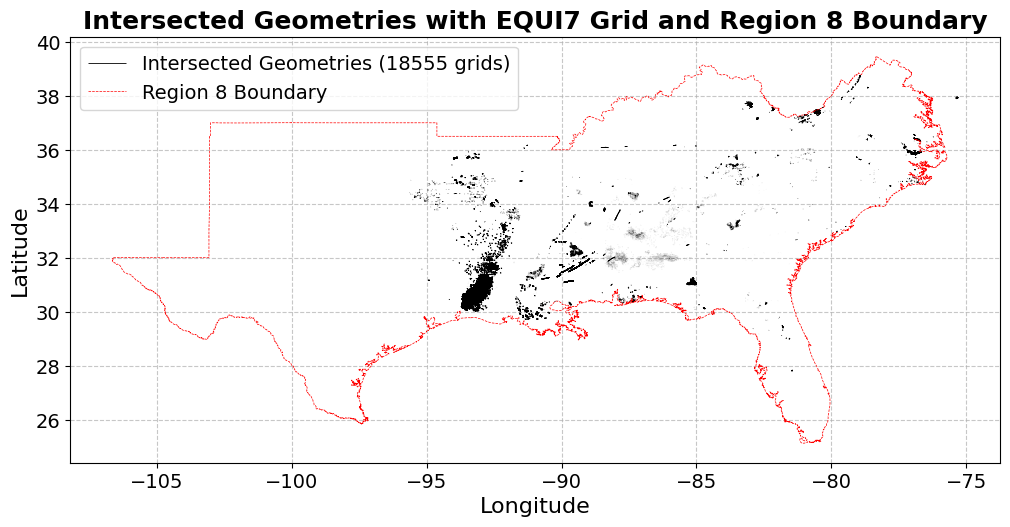

In [91]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Define a POLYGON geometry
usa_filepath = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
usa = gpd.read_file(usa_filepath)
country = usa[usa.REGION == "08"]
region = country.explode()[0:1]

# Example data for region 8
region = country.explode()[0:1]  # Adjust this line as needed to select region 8
# Plot the boundary of the intersected geometries and region 8 with enhancements
fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

# Plot the boundaries of intersected_gdf
gdf_area.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)
unique_id_a_count = len(gdf_area['ID_E'].unique())

# Plot the boundary of region 8
region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

# Customize the plot appearance
ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Set the aspect ratio of the plot to be equal
ax.set_aspect('equal')

# Optional: Add a legend if needed
ax.legend([f'Intersected Geometries ({unique_id_a_count} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

plt.show()


In [6]:
refdm = gpd.read_file('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/overlapping_results/radar_enhanced_forest_disturbance_mapping_overlap.shp')
refdm

,USDA_IDX,S1_YEAR,S1_TILE,S1CD_IDX,ID_E,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,ID_O,O_Year,O_DCA_ID,O_Year_dif,area_km2,geometry
0,bark_beetle_2019_33525,2020,E084N024T3,8796,46942,bark_beetle,2019,8,Mortality,2,None,None,None,None,0.636723,"MULTIPOLYGON (((-94.90383 31.16151, -94.90325 ..."
1,bark_beetle_2019_33526,2020,E084N024T3,8797,46943,bark_beetle,2019,8,Mortality,2,None,None,None,None,0.429331,"MULTIPOLYGON (((-94.16938 30.44613, -94.16938 ..."
2,bark_beetle_2019_33527,2020,E084N024T3,8798,46944,bark_beetle,2019,8,Mortality,2,None,None,None,None,0.218768,"MULTIPOLYGON (((-94.02645 31.88864, -94.02665 ..."
3,bark_beetle_2019_47793,2020,E084N024T3,20725,46938,bark_beetle,2019,8,Mortality,2,46939,2019,bark_beetle,0,0.371782,"MULTIPOLYGON (((-94.92521 31.15554, -94.92521 ..."
4,bark_beetle_2019_47794,2020,E084N024T3,20728,46939,bark_beetle,2019,8,Mortality,2,46938,2019,bark_beetle,0,0.126259,"MULTIPOLYGON (((-94.92367 31.15689, -94.92309 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39871,bark_beetle_2018_33298,2019,E093N027T3,8642,45155,bark_beetle,2018,8,Mortality,2,None,None,None,None,0.017537,"MULTIPOLYGON (((-83.71353 33.12205, -83.71353 ..."
39872,bark_beetle_2018_33299,2019,E093N027T3,8643,45156,bark_beetle,2018,8,Mortality,2,None,None,None,None,0.003837,"POLYGON ((-83.70583 33.15208, -83.70544 33.152..."
39873,wind_2019_33349,2019,E093N027T3,8680,45673,wind,2019,8,Main stem Broken or Uprooted,7,None,None,None,None,0.926463,"MULTIPOLYGON (((-85.37323 32.45155, -85.37342 ..."
39874,wind_2020_35158,2019,E093N027T3,9258,56531,wind,2020,8,Branch Breakage,6,None,None,None,None,0.371348,"MULTIPOLYGON (((-86.04258 34.06526, -86.04315 ..."


In [7]:
# Calculate the number of unique 'ID_E' values
unique_id_USDA_IDX_count = len(refdm['USDA_IDX'].unique())
# Calculate the number of unique 'ID_E' values
unique_id_ID_E_count = len(refdm['ID_E'].unique())
print(f"Number of unique 'ID_E': {unique_id_ID_E_count}")
print(f"Number of unique 'USDA_IDX': {unique_id_USDA_IDX_count}")

Number of unique 'ID_E': 16086
Number of unique 'USDA_IDX': 16086


/tmp/ipykernel_3429778/882955453.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]
/tmp/ipykernel_3429778/882955453.py:11: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  region = country.explode()[0:1]  # Adjust this line as needed to select region 8


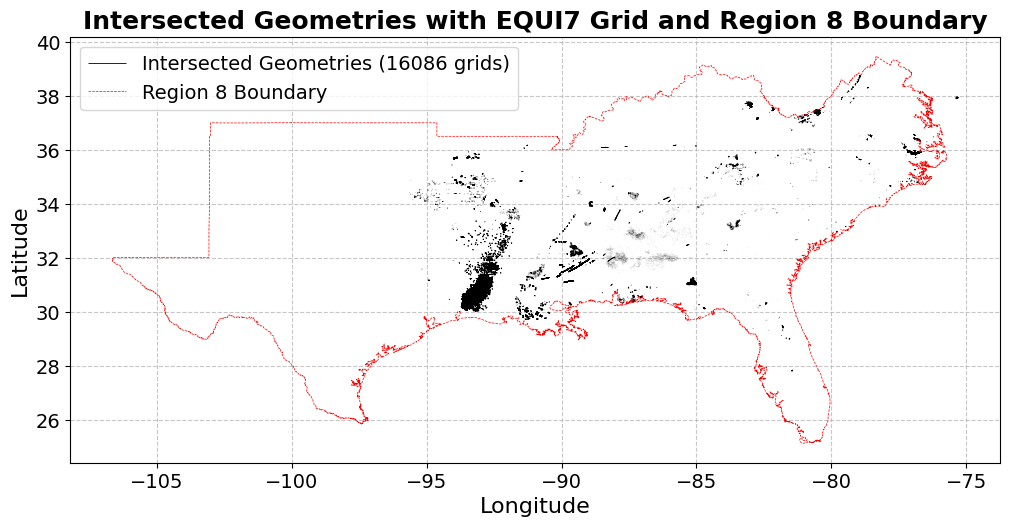

In [106]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Define a POLYGON geometry
usa_filepath = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
usa = gpd.read_file(usa_filepath)
country = usa[usa.REGION == "08"]
region = country.explode()[0:1]

# Example data for region 8
region = country.explode()[0:1]  # Adjust this line as needed to select region 8
# Plot the boundary of the intersected geometries and region 8 with enhancements
fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

# Plot the boundaries of intersected_gdf
gdf_area.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)
unique_id_ID_E_count = len(refdm['ID_E'].unique())

# Plot the boundary of region 8
region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

# Customize the plot appearance
ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Set the aspect ratio of the plot to be equal
ax.set_aspect('equal')

# Optional: Add a legend if needed
ax.legend([f'Intersected Geometries ({unique_id_ID_E_count} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

plt.show()


# Pretty plot Overlap

In [8]:
import pandas as pd

def generate_intersection_df(gdf):
    """
    Generate a DataFrame with intersection counts for all DCA_IDs, including a DCA_Short column.
    
    Parameters:
    gdf (DataFrame): DataFrame containing the overlap analysis with 'DCA_ID_List' and 'O_Year_diff'.
    
    Returns:
    DataFrame: A DataFrame containing intersections with an additional column for the original DCA_ID and DCA_Short.
    """
    # Define the mapping for DCA_IDs
    dca_id_mapping = {
        'wind': 'W',
        'bark_beetle': 'BB',
        'fire': 'F',
        'drought': 'D',
        'defoliators': 'DF',
        'other_abiotics': 'OA',
        'other': 'O',
        'other_biotics': 'OB'
    }
    
    # Create a DataFrame to store all intersections
    all_intersections = []

    # Get unique DCA_IDs
    unique_dca_ids = gdf['DCA_ID'].explode().unique()

    for target_dca_id in unique_dca_ids:
        # Filter the DataFrame to include only rows where the target_dca_id is in 'DCA_ID_List'
        filtered_df = gdf[gdf['DCA_ID'].apply(lambda x: target_dca_id in x)]
        
        # Create a dictionary to store the counts of intersections, grouped by year difference
        intersection_counts = {}
        
        # Iterate over each filtered row
        for _, row in filtered_df.iterrows():
            dca_ids = row['O_DCA_ID']
            year_diffs = row['O_Year_dif']
            
            # Ensure dca_ids and year_diffs are lists
            if isinstance(dca_ids, str):
                dca_ids = [dca_ids]
            if not isinstance(year_diffs, list):
                year_diffs = [year_diffs]
            
            # Check if lengths are the same
            if len(dca_ids) != len(year_diffs):
                raise ValueError("Mismatch between lengths of dca_ids and year_diffs")
            
            # Process each pair
            for dca_id, year_diff in zip(dca_ids, year_diffs):
                if dca_id not in intersection_counts:
                    intersection_counts[dca_id] = {}
                if year_diff not in intersection_counts[dca_id]:
                    intersection_counts[dca_id][year_diff] = 0
                intersection_counts[dca_id][year_diff] += 1
        
        # Convert the intersection counts to a DataFrame
        plot_data = []
        for dca_id_code, year_diffs in intersection_counts.items():
            for year_diff, count in year_diffs.items():
                plot_data.append({
                    'original_dca_id': target_dca_id, 
                    'DCA_ID': dca_id_code, 
                    'Year Offset': year_diff, 
                    'Count': count
                })
        
        intersection_df = pd.DataFrame(plot_data)
        all_intersections.append(intersection_df)

    # Concatenate all DataFrames into one
    final_df = pd.concat(all_intersections, ignore_index=True)
    
    # Map the DCA_ID and original_dca_id to their short forms using dca_id_mapping
    final_df['DCA_Short'] = final_df['DCA_ID'].map(dca_id_mapping)
    final_df['Original_DCA_Short'] = final_df['original_dca_id'].map(dca_id_mapping)
    
    return final_df


In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines

def plot_overlap(df):
    # Define the correct palette based on unique values
    palette_blue = {
        '-1': '#2C5DA6', 
        '0': '#000C7A', 
        '1': '#6FD7E7'
    }

    # Define the desired order for 'Year_Diff'
    year_diff_order = ['-1', '0', '1']

    # Create the catplot
    g = sns.catplot(
        data=df, 
        x="DCA_Short", 
        y="Count", 
        col="original_dca_id", 
        hue="Year Offset",  # Use hue to separate by Year_Diff
        kind="bar",
        saturation=0.7, 
        height=4,
        width=0.9,
        aspect=.6,
        estimator="sum",
        legend='full',
        palette=palette_blue,  # Use the updated palette
        hue_order=year_diff_order  # Set the order for Year_Diff
    )

    # Define a proportional offset factor
    offset_factor = 0.7  # 10% of the bar height

    # Iterate over each subplot to add markers
    for ax in g.axes.flat:
        # Set y-axis to log scale
        ax.set_yscale('log')
        # Add bar labels to all bars
        for container in ax.containers:
            ax.bar_label(container, fontsize=8, label_type='edge', color='black', padding=2)  # Add labels at the edge of the bars


        # Update the title to just show the original_dca_id without the prefix
        tt = ax.get_title().split(" = ")[-1]
        title = ' '.join(word.capitalize() for word in tt.split('_'))
        ax.set_title(title)

        # Find the subset where Year_Diff = 0
        subset = res[(res['Year Offset'] == '0') & (res['original_dca_id'] == tt.lower())]

        # Ensure there is at least one entry
        if not subset.empty:
            # Identify the row with the maximum count
            max_row = subset.loc[subset['Count'].idxmax()]

            x_pos = max_row['DCA_Short']
            y_pos = max_row['Count']
            
            # Find the x position of the bar to place the star marker
            x_ticks = [tick.get_text() for tick in ax.get_xticklabels()]
            x_index = x_ticks.index(x_pos)
            
            # Calculate a proportional offset
            y_limit = ax.get_ylim()[1]  # Get the upper limit of y-axis
            offset = offset_factor * (y_limit / y_pos)  # Proportional offset
            
            # Plot a star marker on top of the bar with a proportional offset
            ax.plot(x_index, y_pos * (1.5 + offset_factor), "*", markersize=10, color="r")

        # Add a single x-axis label under all columns
        plt.subplots_adjust(bottom=0.15)  # Adjust to make space for the label
        g.set_axis_labels(x_var=" ", y_var="Count")

    g.fig.text(0.5, 0.02, 'DCA', ha='center', va='center', fontsize=16)

    # Extract unique DCA_Short and corresponding DCA_ID descriptions
    dca_mapping = {
        'BB': 'Bark Beetle',
        'W': 'Wind',
        'F': 'Fire',
        'D': 'Drought',
        'DF': 'Defoliators'
    }

    # Create legend elements without colored patches
    legend_elements = [lines.Line2D([0], [0], color='black', linestyle='-', linewidth=0, label=f'{key} = {description}')
                    for key, description in dca_mapping.items()]
    # Add the legend to the figure
    g.fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=14)
    # Add a header to the entire plot
    #g.fig.suptitle('Disturbance Interactions per yearly offset', fontsize=26)
    plt.savefig('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/p1_f9_disturbance_interactions_per_yearly_offset.png', dpi=300, bbox_inches='tight')

    plt.show()


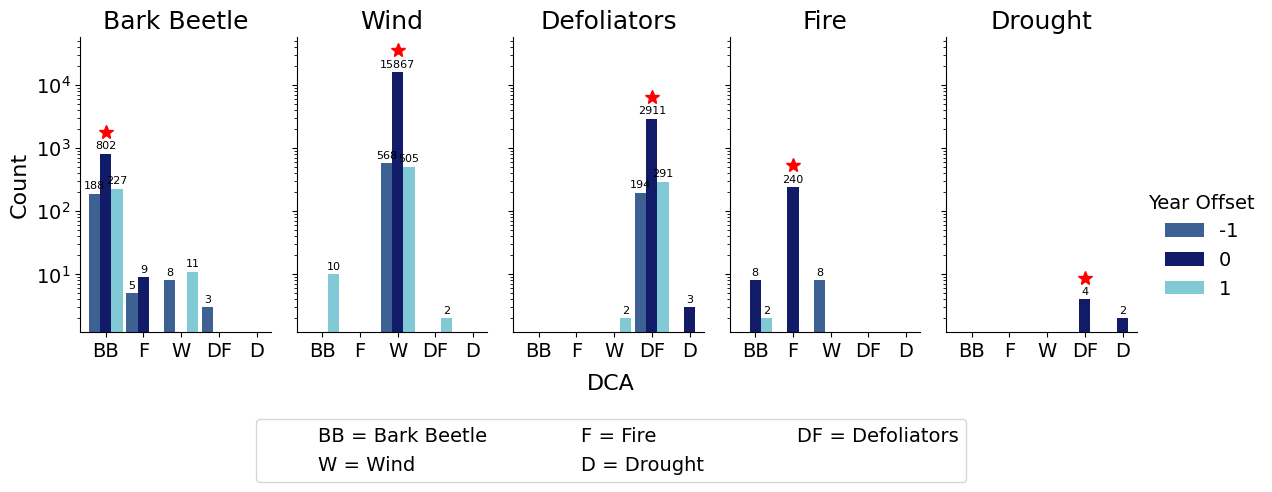

In [53]:
refdm = gpd.read_file('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/overlapping_results/radar_enhanced_forest_disturbance_mapping_overlap.shp')
excluded_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
filtered_df = refdm[~refdm['O_DCA_ID'].isin(excluded_types)].copy()
filtered_df = filtered_df[filtered_df['ID_O'].notna()]
res = generate_intersection_df(filtered_df)
plot_overlap(res)

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines

def plot_overlap(df):
    # Define the correct palette based on unique values
    palette_blue = {
        '-1': '#2C5DA6', 
        '0': '#000C7A', 
        '1': '#6FD7E7'
    }

    # Define the desired order for 'Year_Diff'
    year_diff_order = ['-1', '0', '1']

    # Create the catplot
    g = sns.catplot(
        data=df, 
        x="DCA_Short", 
        y="Count", 
        col="original_dca_id", 
        hue="Year Offset",  # Use hue to separate by Year_Diff
        kind="bar",
        saturation=0.7, 
        height=4,
        width=0.9,
        aspect=.6,
        estimator="sum",
        legend='full',
        palette=palette_blue,  # Use the updated palette
        hue_order=year_diff_order  # Set the order for Year_Diff
    )

    # Define a proportional offset factor
    offset_factor = 0.7  # 10% of the bar height

    # Iterate over each subplot to add markers
    for ax in g.axes.flat:
        # Set y-axis to log scale
        ax.set_yscale('log')
        # Add bar labels to all bars
        for container in ax.containers:
            ax.bar_label(container, fontsize=8, label_type='edge', color='black', padding=2)  # Add labels at the edge of the bars


        # Update the title to just show the original_dca_id without the prefix
        tt = ax.get_title().split(" = ")[-1]
        title = ' '.join(word.capitalize() for word in tt.split('_'))
        ax.set_title(title)

        # Find the subset where Year_Diff = 0
        subset = res[(res['Year Offset'] == '0') & (res['original_dca_id'] == tt.lower())]

        # Ensure there is at least one entry
        if not subset.empty:
            # Identify the row with the maximum count
            max_row = subset.loc[subset['Count'].idxmax()]

            x_pos = max_row['DCA_Short']
            y_pos = max_row['Count']
            
            # Find the x position of the bar to place the star marker
            x_ticks = [tick.get_text() for tick in ax.get_xticklabels()]
            x_index = x_ticks.index(x_pos)
            
            # Calculate a proportional offset
            y_limit = ax.get_ylim()[1]  # Get the upper limit of y-axis
            offset = offset_factor * (y_limit / y_pos)  # Proportional offset
            
            # Plot a star marker on top of the bar with a proportional offset
            ax.plot(x_index, y_pos * (1.5 + offset_factor), "*", markersize=10, color="r")

        # Add a single x-axis label under all columns
        plt.subplots_adjust(bottom=0.15)  # Adjust to make space for the label
        g.set_axis_labels(x_var=" ", y_var="Count")

    g.fig.text(0.5, 0.02, 'DCA', ha='center', va='center', fontsize=16)

    # Extract unique DCA_Short and corresponding DCA_ID descriptions
    dca_mapping = {
        'BB': 'Bark Beetle',
        'W': 'Wind',
        'F': 'Fire',
        'D': 'Drought',
        'DF': 'Defoliators',
        'O': 'Other', 
        'MD': 'Multi_damage', 
        'OA': 'Other Abiotic',
        'OB': 'Other Biotic'
    }

    # Create legend elements without colored patches
    legend_elements = [lines.Line2D([0], [0], color='black', linestyle='-', linewidth=0, label=f'{key} = {description}')
                    for key, description in dca_mapping.items()]
    # Add the legend to the figure
    g.fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=14)
    # Add a header to the entire plot
    #g.fig.suptitle('Disturbance Interactions per yearly offset', fontsize=26)
    plt.savefig('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/p1_f9_disturbance_interactions_per_yearly_offset.png', dpi=300, bbox_inches='tight')

    plt.show()


In [63]:
#filtered_df = gdf_overlap[~gdf_overlap['O_DCA_ID'].isin(excluded_types)].copy()
filtered_df = merged_gdf[merged_gdf['ID_O'].notna()]
res = generate_intersection_df(filtered_df)
plot_overlap(res)

KeyError: 'O_DCA_ID'